# IA<a class="tocSkip">
## INTELIGENCIA ARTIFICIAL <a class="tocSkip">
### Ingenieria Electrónica <a class="tocSkip">
### Universidad Popular del Cesar <a class="tocSkip">
### Prof.: Jose Ramón Iglesias Gamarra - [https://github.com/joseramoniglesias/](https://github.com/joseramoniglesias/) <a class="tocSkip">
  **joseiglesias@unicesar.edu.co**

# Optimización en el diseño de instalaciones de autoconsumo

In [1]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Simulación de consumo energético

In [3]:
date_range = pd.date_range(start="2025-01-01", periods=7*24, freq='h')
np.random.seed(0)
n_days = 7
hours_per_day = 24

# Creamos una señal base para un solo día
daily_hours = np.arange(hours_per_day)
mu = 19  # pico a las 19:00
sigma = 3
daily_pattern = 1.75 + 2 * np.exp(-0.5 * ((daily_hours - mu) / sigma) ** 2)

# Repetimos la señal base durante 7 días
pattern_week = np.tile(daily_pattern, n_days)

# Añadimos ruido aleatorio
random_noise = np.random.normal(0, 0.2, size=len(pattern_week))
consumo = pattern_week + random_noise

consumo = np.clip(consumo, 0, None)  # Evitar valores negativos

df = pd.DataFrame(index=date_range)
df['Consumo'] = consumo

## Simulación de generación fotovoltaica

In [4]:
solar_generation = []

for timestamp in df.index:
    hour = timestamp.hour
    if 7 <= hour <= 19:
        # Simulación con un perfil solar tipo campana
        gen = np.sin(np.pi * (hour - 7) / 12) * 1  # pico máximo de 3.5 kWh
    else:
        gen = 0
    solar_generation.append(gen)

df['GeneracionFV'] = solar_generation

solar_generation_2times = solar_generation * 2

## Visualización de las señales

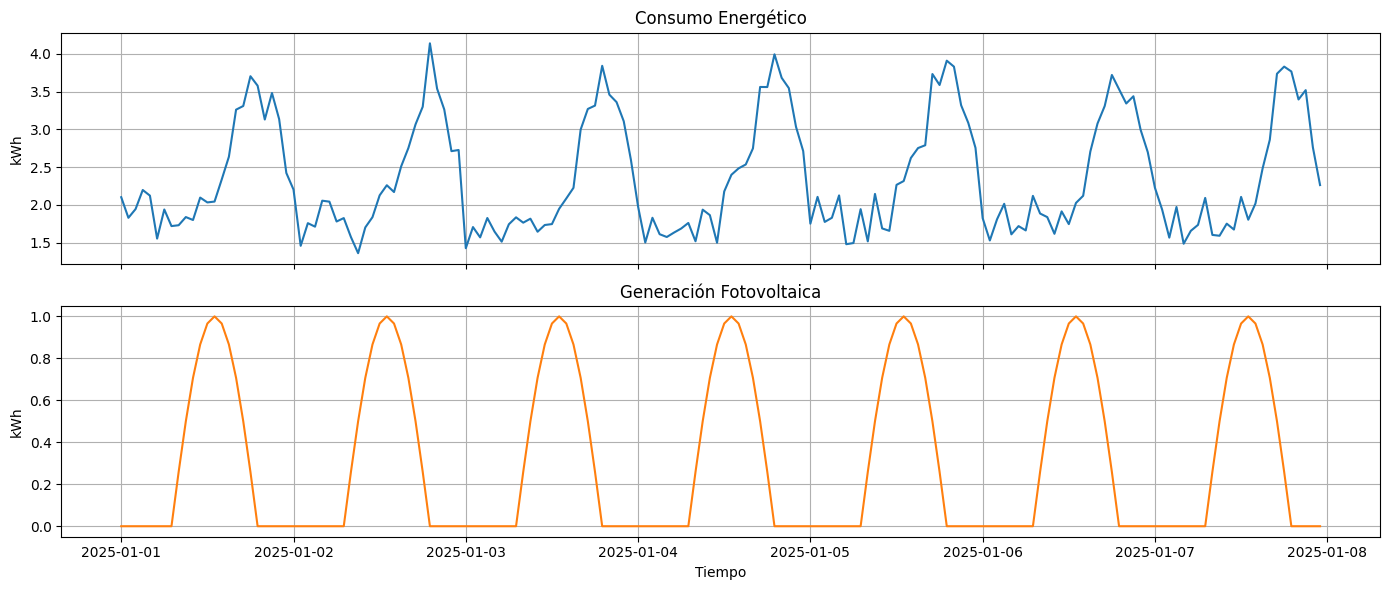

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Primer subplot: Consumo
axs[0].plot(df.index, df['Consumo'], color='tab:blue')
axs[0].set_title("Consumo Energético")
axs[0].set_ylabel("kWh")
axs[0].grid(True)

# Segundo subplot: Generación FV
axs[1].plot(df.index, df['GeneracionFV'], color='tab:orange')
axs[1].set_title("Generación Fotovoltaica")
axs[1].set_ylabel("kWh")
axs[1].grid(True)

plt.xlabel("Tiempo")
plt.tight_layout()
plt.show()

## Dimensionado iterativo del sistema FV

In [6]:
%%capture

resultados_bateria = []

total_consumo = df['Consumo'].sum()
factores = np.arange(1, 10, 0.5)  # de 0.5 a 5.0
autoconsumo_prev = 0  # para calcular incremento

for f in factores:
    generacion = df['GeneracionFV'] * f
    consumo = df['Consumo']

    energia_instantanea = np.minimum(consumo, generacion)
    excedente = np.clip(generacion - consumo, 0, None)
    deficit = np.clip(consumo - generacion, 0, None)

    # Simulamos batería infinita: el excedente se acumula, se usa para cubrir déficits
    energia_bateria = 0
    energia_bateria_usada = []

    for i in range(len(df)):
        if deficit[i] > 0:
            usada = min(energia_bateria, deficit[i])
            energia_bateria_usada.append(usada)
            energia_bateria -= usada
        else:
            energia_bateria_usada.append(0.0)

        energia_bateria += excedente[i]

    energia_bateria_usada = np.array(energia_bateria_usada)
    autoconsumo_total = energia_instantanea.sum() + energia_bateria_usada.sum()
    porcentaje_cubierto = autoconsumo_total / total_consumo * 100

    if autoconsumo_prev == 0:
        incremento = 0
    else:
        incremento = (autoconsumo_total - autoconsumo_prev) / autoconsumo_prev * 100

    resultados_bateria.append({
        'Valor pico de generación': f,
        'Autoconsumo': autoconsumo_total,
        '%_Cobertura': porcentaje_cubierto,
        '%_Incremento_autoconsumo': incremento
    })

    autoconsumo_prev = autoconsumo_total

df_autoconsumo = pd.DataFrame(resultados_bateria)

# Supuestos: eficiencia del panel solar en kWp por m²
eficiencia_baja = 0.06  # kWp/m²
eficiencia_alta = 0.15  # kWp/m²

# Calcular superficie necesaria en m² para cada caso
df_autoconsumo['Superficie_min_m2'] = df_autoconsumo['Valor pico de generación'] / eficiencia_alta
df_autoconsumo['Superficie_max_m2'] = df_autoconsumo['Valor pico de generación'] / eficiencia_baja

df_autoconsumo = df_autoconsumo.round(2)

## Presentación de resultados para el diseño del sistema FV



In [7]:
print(df_autoconsumo.to_string(index=False))

 Valor pico de generación  Autoconsumo  %_Cobertura  %_Incremento_autoconsumo  Superficie_min_m2  Superficie_max_m2
                      1.0        53.17        13.44                      0.00               6.67              16.67
                      1.5        79.76        20.16                     50.00              10.00              25.00
                      2.0       106.34        26.88                     33.33              13.33              33.33
                      2.5       132.93        33.60                     25.00              16.67              41.67
                      3.0       159.51        40.32                     20.00              20.00              50.00
                      3.5       186.10        47.05                     16.67              23.33              58.33
                      4.0       212.68        53.77                     14.29              26.67              66.67
                      4.5       239.27        60.49                     

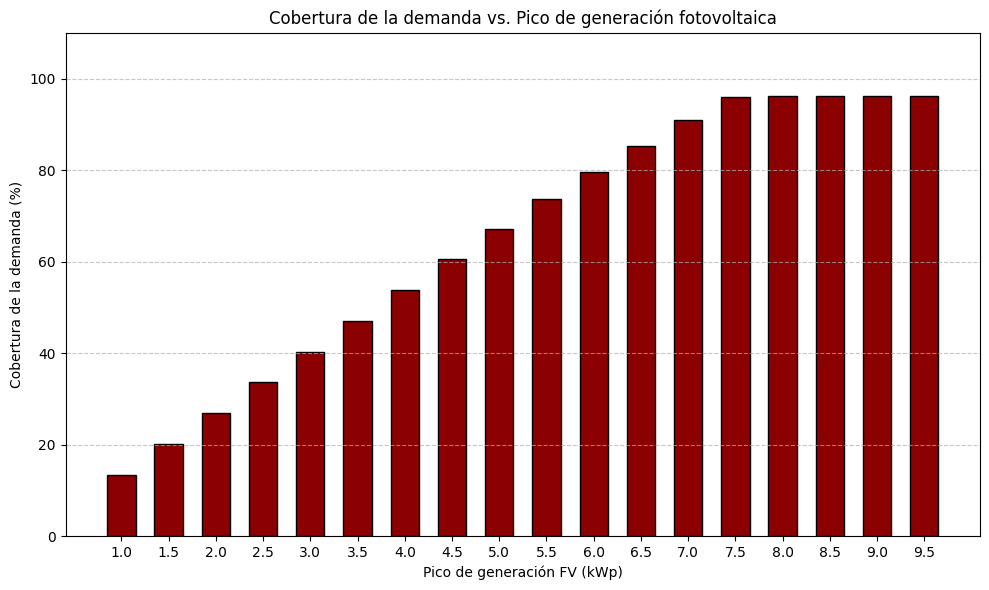

In [8]:
plt.figure(figsize=(10, 6))
plt.bar(df_autoconsumo['Valor pico de generación'],
        df_autoconsumo['%_Cobertura'],
        width=0.3,
        color='darkred',
        edgecolor='black')
plt.xlabel("Pico de generación FV (kWp)")
plt.ylabel("Cobertura de la demanda (%)")
plt.title("Cobertura de la demanda vs. Pico de generación fotovoltaica")
plt.xticks(df_autoconsumo['Valor pico de generación'])
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Dimensionado iterativo del sistema de almacenamiento de energía

In [9]:
%%capture

capacidades_bateria = np.arange(2.5, 40, 2.5)  # de 5 a 40 kWh, pasos de 5

resultados_bateria_cap = []

generacion = df['GeneracionFV']*7.5  # sin escala, generación fija
consumo = df['Consumo']
total_consumo = consumo.sum()
autoconsumo_prev = 0

for capacidad in capacidades_bateria:
    energia_bateria = 0
    energia_bateria_usada = []
    energia_instantanea = np.minimum(consumo, generacion)
    excedente = np.clip(generacion - consumo, 0, None)
    deficit = np.clip(consumo - generacion, 0, None)

    for i in range(len(df)):
        # Primero uso batería para déficit
        if deficit[i] > 0:
            usada = min(energia_bateria, deficit[i])
            energia_bateria -= usada
            energia_bateria_usada.append(usada)
        else:
            energia_bateria_usada.append(0.0)

        # Luego guardo excedente en batería hasta capacidad máxima
        energia_bateria += excedente[i]
        energia_bateria = min(energia_bateria, capacidad)

    energia_bateria_usada = np.array(energia_bateria_usada)
    autoconsumo_total = energia_instantanea.sum() + energia_bateria_usada.sum()
    porcentaje_cubierto = autoconsumo_total / total_consumo * 100

    if autoconsumo_prev == 0:
        incremento = 0
    else:
        incremento = (autoconsumo_total - autoconsumo_prev) / autoconsumo_prev * 100

    resultados_bateria_cap.append({
        'Capacidad_bateria_kWh': capacidad,
        'Autoconsumo_kWh': autoconsumo_total,
        '%_Cobertura': porcentaje_cubierto,
        '%_Incremento_autoconsumo': incremento
    })

    autoconsumo_prev = autoconsumo_total

df_autoconsumo_bateria = pd.DataFrame(resultados_bateria_cap)

df_autoconsumo_bateria = df_autoconsumo_bateria.round(2)

## Presentación de resultados para el diseño del sistema de almacenamiento

In [10]:
print(df_autoconsumo_bateria.to_string(index=False))

 Capacidad_bateria_kWh  Autoconsumo_kWh  %_Cobertura  %_Incremento_autoconsumo
                   2.5           186.92        47.25                      0.00
                   5.0           204.42        51.68                      9.36
                   7.5           221.92        56.10                      8.56
                  10.0           239.42        60.52                      7.89
                  12.5           256.92        64.95                      7.31
                  15.0           274.42        69.37                      6.81
                  17.5           291.92        73.80                      6.38
                  20.0           307.02        77.61                      5.17
                  22.5           322.02        81.41                      4.89
                  25.0           337.02        85.20                      4.66
                  27.5           352.02        88.99                      4.45
                  30.0           367.02        92.78

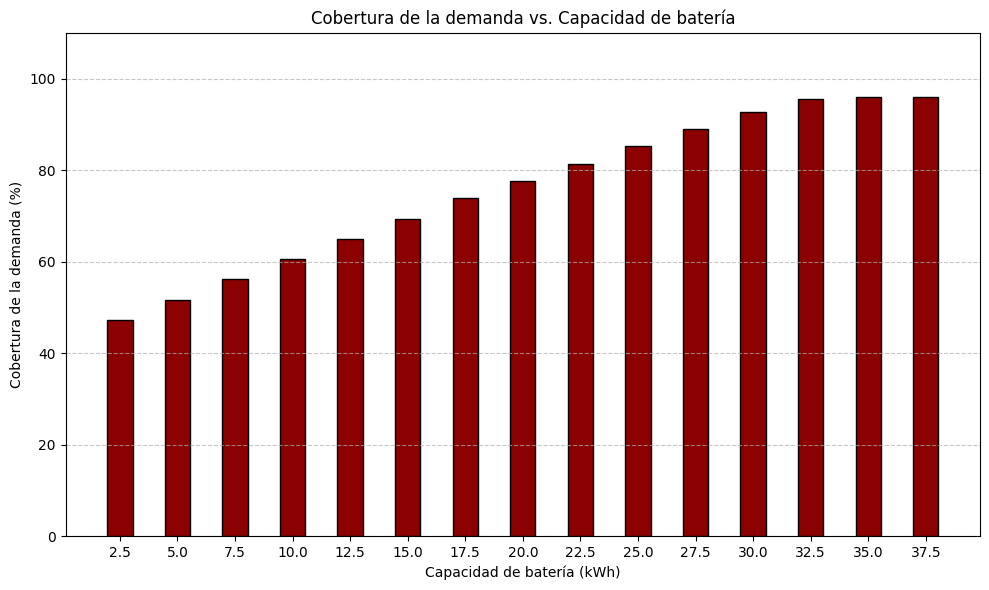

In [11]:
plt.figure(figsize=(10, 6))
plt.bar(df_autoconsumo_bateria['Capacidad_bateria_kWh'],
        df_autoconsumo_bateria['%_Cobertura'],
        width=1.1,
        color='darkred',
        edgecolor='black')
plt.xlabel("Capacidad de batería (kWh)")
plt.ylabel("Cobertura de la demanda (%)")
plt.title("Cobertura de la demanda vs. Capacidad de batería")
plt.xticks(df_autoconsumo_bateria['Capacidad_bateria_kWh'])
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()